In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw
from collections import Counter
from matplotlib.colors import to_hex
from sklearn.preprocessing import RobustScaler, StandardScaler
from collections import defaultdict
from pycirclize import Circos
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

In [2]:
# Define some paths
root = '../../../Documents/mtb-targeted-protein-degradation/notebooks'

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "output", "pocket_detection_data.csv"))
PROTEINS = sorted(set(pocket_detection_data['Uniprot AC']))

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

# Prepare dicts
DOCKING_RESULTS = {}
DOCKING_RESULTS['Enamine-DL-HLL-100'] = dict()
DOCKING_RESULTS['EnamineREAL10B'] = dict()

# Get SMILES
ID_TO_SMILES = {}
ID_TO_SMILES['Enamine-DL-HLL-100'] = pickle.load(open(os.path.join(root, "..", "output", "enamine_characterization", "ID_TO_SMI.pkl"), "rb"))
df = pd.read_csv(os.path.join(root, "..", "output", "unidock_REAL_docking", 'inference_10B', 'clustered_compounds.csv'))
ID_TO_SMILES['EnamineREAL10B'] = {i: j for i,j in zip(df['id'], df['smiles'])}
del df

# For each pocket - ORIGINAL
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "output", "unidock_docking", 'docking_results')
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
    assert len(scores) == 100154
    DOCKING_RESULTS['Enamine-DL-HLL-100'][pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket - REAL 2
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "output", "unidock_REAL_docking_2", 'docking_results')
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))
    assert len(scores) == 99105
    DOCKING_RESULTS['EnamineREAL10B'][pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

100%|██████████| 276/276 [00:16<00:00, 16.85it/s]


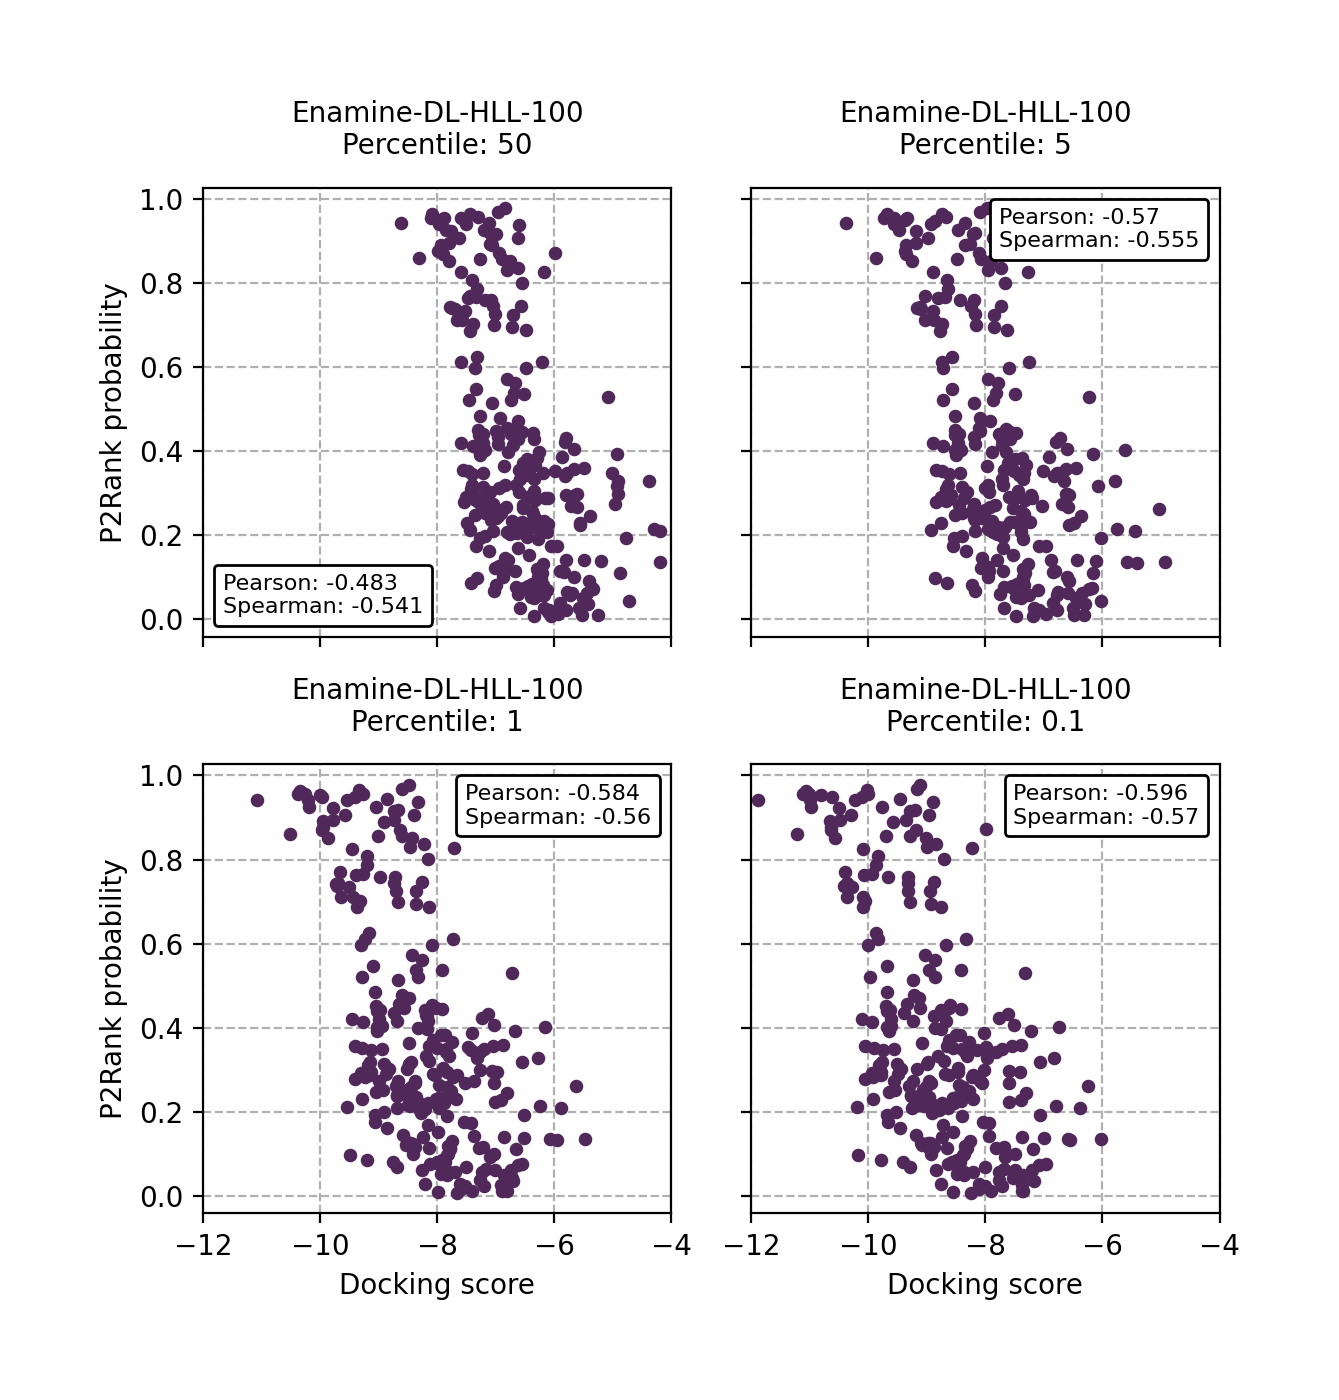

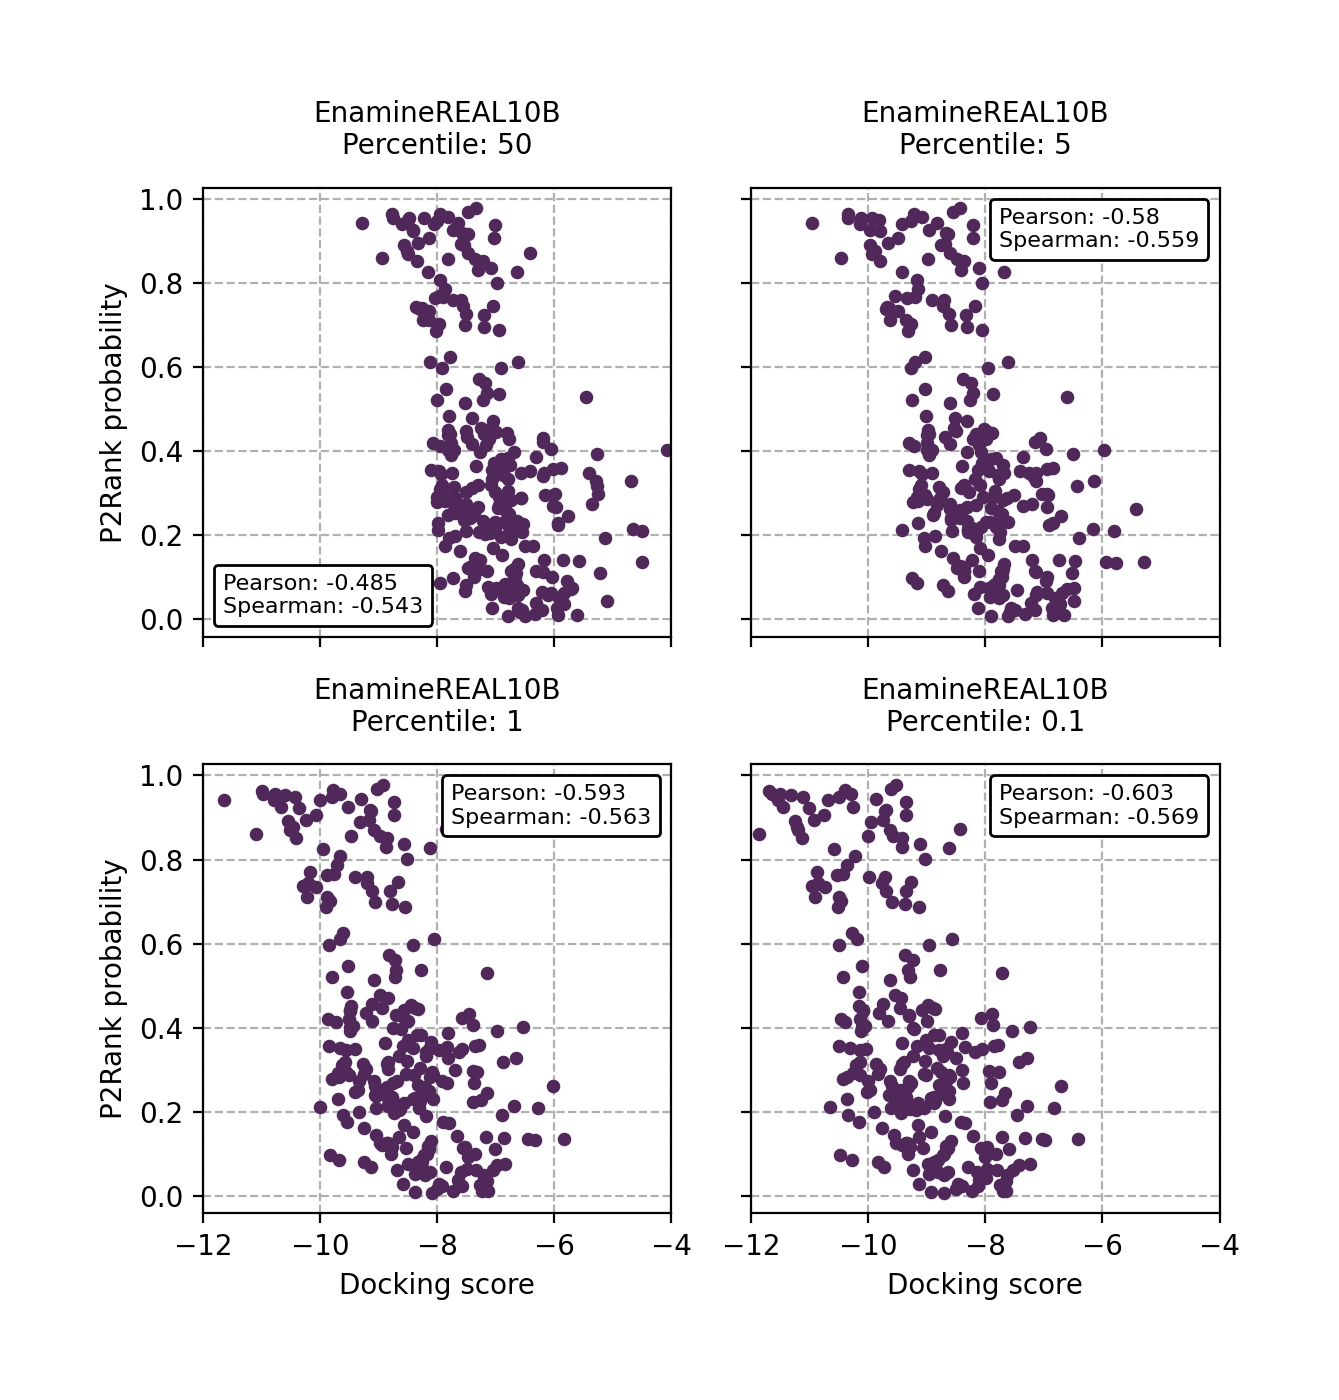

In [3]:
for lib in DOCKING_RESULTS:
    fig, ax = plt.subplots(2, 2, figsize=(6, 6.3), sharex=True, sharey=True, dpi=200)
    percentiles = [50, 5, 1, 0.1]
    for (c1, c2), perc in zip([[0,0], [0,1], [1,0], [1,1]], percentiles):
        x, y = [], []
        for fn, pn, ps, pp in pocket_detection_data[['File name', 'Pocket number', 'Pocket score', 'Pocket probability']].values:
            pocket = f'{fn.replace(".pdb", "")}_pocket_{pn}'
            x.append(np.percentile(list(DOCKING_RESULTS[lib][pocket].values()), perc))
            y.append(pp)
        pr_st, pr_pval = ss.pearsonr(x, y)
        sp_st, sp_pval = ss.spearmanr(x, y)
        label = f"Pearson: {round(pr_st, 3)}\nSpearman: {round(sp_st, 3)}"
        ax[c1][c2].scatter(x, y, s=15, c="#50285A", label=label, zorder=2)
        ax[c1][c2].set_title(f"{lib}\nPercentile: {perc}", pad=12, size=10)
        ax[c1][c2].grid(linestyle='--', zorder=-2)
        ax[c1][c2].set_xlim([-12, -4])
        if c2 == 0:
            ax[c1][c2].set_ylabel("P2Rank probability")
        if c1 == 1:
            ax[c1][c2].set_xlabel("Docking score")
        if c1 == 0 and c2 == 0:
            ax[c1][c2].legend(loc='lower left', framealpha=1, edgecolor='k', prop={'size': 8}, handlelength=0, handletextpad=0, markerscale=0)
        else:
            ax[c1][c2].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8}, handlelength=0, handletextpad=0, markerscale=0)
    plt.tight_layout()
    plt.show()

In [4]:
MEDIANS = {}
MEDIANS['Enamine-DL-HLL-100'] = dict()
MEDIANS['EnamineREAL10B'] = dict()
POCKETS = sorted(DOCKING_RESULTS['Enamine-DL-HLL-100'])
for pocket in sorted(DOCKING_RESULTS['Enamine-DL-HLL-100']):
    MEDIANS['Enamine-DL-HLL-100'][pocket] = np.median(list(DOCKING_RESULTS['Enamine-DL-HLL-100'][pocket].values()))
    MEDIANS['EnamineREAL10B'][pocket] = np.median(list(DOCKING_RESULTS['EnamineREAL10B'][pocket].values()))

In [5]:
for lib in ['Enamine-DL-HLL-100', 'EnamineREAL10B']:
    print(lib)
    for cut in [-5, -6, -7, -8]:
        pockets = set([i for i in MEDIANS[lib] if MEDIANS[lib][i] > cut])
        proteins_kept = set([i.split("_")[1] for i in POCKETS if i not in pockets])
        print(f"{len(pockets)} pockets (21 --> {len(proteins_kept)} proteins) have a median docking score > {cut}")
    print("\n")

Enamine-DL-HLL-100
16 pockets (21 --> 21 proteins) have a median docking score > -5
58 pockets (21 --> 21 proteins) have a median docking score > -6
182 pockets (21 --> 18 proteins) have a median docking score > -7
272 pockets (21 --> 3 proteins) have a median docking score > -8


EnamineREAL10B
8 pockets (21 --> 21 proteins) have a median docking score > -5
35 pockets (21 --> 21 proteins) have a median docking score > -6
117 pockets (21 --> 21 proteins) have a median docking score > -7
246 pockets (21 --> 11 proteins) have a median docking score > -8




In [6]:
lib = 'Enamine-DL-HLL-100'

Building matrix...


  0%|          | 0/218 [00:00<?, ?it/s]

100%|██████████| 218/218 [00:06<00:00, 34.24it/s]


Scaling matrix...
Perc. 50: 0.016351837843237002
Perc. 10: -1.2633597574158926
Perc. 1: -2.4822595085459653
Perc. 0.5: -2.794476911311552
Perc. 0.01: -4.325901237099233
Getting hits...


100%|██████████| 218/218 [00:08<00:00, 24.83it/s]


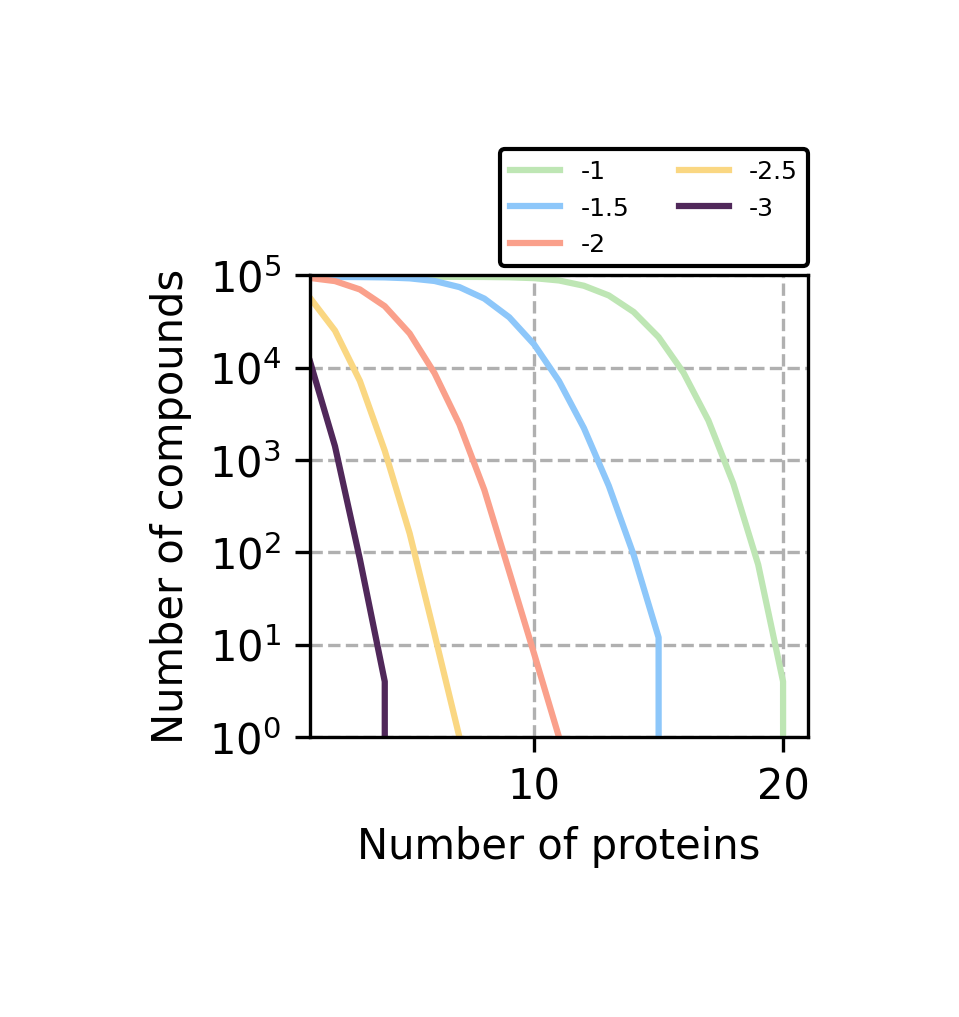

In [45]:
# Define matrix
print("Building matrix...")
pockets_to_use = [i for i in POCKETS if MEDIANS[lib][i] < -6]
medians = [MEDIANS[lib][i] for i in pockets_to_use]
pockets_to_use = np.array(pockets_to_use)[np.argsort(medians)]
cpds = np.array(sorted(DOCKING_RESULTS[lib][pockets_to_use[0]]))
X = np.zeros((len(cpds), len(pockets_to_use)))
for c, pocket in enumerate(tqdm(pockets_to_use)):
    scores = [DOCKING_RESULTS[lib][pocket][cpd] for cpd in cpds]
    X[:, c] = scores

# Scale matrix
print("Scaling matrix...")
X_scaled = RobustScaler().fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_scaled.T).T

values = X_scaled.flatten()
print(f"Perc. 50: {np.percentile(values, 50)}")
print(f"Perc. 10: {np.percentile(values, 10)}")
print(f"Perc. 1: {np.percentile(values, 1)}")
print(f"Perc. 0.5: {np.percentile(values, 0.5)}")
print(f"Perc. 0.01: {np.percentile(values, 0.01)}")

# Get hits per protein and protein per hit
print("Getting hits...")
CUTS = [-1, -1.5, -2, -2.5, -3]
PROTEIN_TO_HITS = {protein: {cut: set() for cut in CUTS} for protein in PROTEINS}
HIT_TO_PROTEINS = {cpd: {cut: set() for cut in CUTS} for cpd in cpds}
for c, pocket in enumerate(tqdm(pockets_to_use)):
    protein = pocket.split("_")[1]
    values = X_scaled[:, c]
    for cut in CUTS:
        compounds = set([cpds[i] for i in np.where(values < cut)[0]])
        PROTEIN_TO_HITS[protein][cut].update(compounds)
        for compound in compounds:
            HIT_TO_PROTEINS[compound][cut].update([protein])

# Prepare plot
n_proteins = [i for i in range(1, 21+1, 1)]
y_proteins = {}
for cut in CUTS:
    y_proteins[cut] = list()
    for N in n_proteins:
        y_proteins[cut].append(len([i for i in HIT_TO_PROTEINS if len(HIT_TO_PROTEINS[i][cut]) > N ]))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.9), dpi=300)
COLORS= ['#50285A', '#FAD782', '#FAA08B', '#8DC7FA', '#BEE6B4'][::-1]
for cut, color in zip(CUTS, COLORS):
    ax.plot(n_proteins, y_proteins[cut], label=str(cut), c=color)
ax.grid(linestyle='--', zorder=-2)
ax.set_ylabel("Number of compounds")
ax.set_xlabel("Number of proteins")
ax.set_yscale('log')
ax.set_ylim([1, 100_000])
ax.set_xlim([1, 21])
ax.set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])
ax.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 6}, ncols=2, bbox_to_anchor=(1.025, 1.3))
plt.tight_layout()
plt.show()

In [46]:
# # Get minimum docking scores per protein
# DOCKING_RESULTS_ORIGINAL_PROTEINS = {i: defaultdict(int) for i in PROTEINS}
# for c1, pocket in tqdm(enumerate(pockets_to_use)):
#     protein = pocket.split("_")[1]
#     for c2, cpd in enumerate(cpds):
#         if cpd not in DOCKING_RESULTS_ORIGINAL_PROTEINS:
#             DOCKING_RESULTS_ORIGINAL_PROTEINS[protein][cpd] = X_scaled[c2][c1]
#         else:
#             DOCKING_RESULTS_ORIGINAL_PROTEINS[protein][cpd] = min(X_scaled[c2][c1], DOCKING_RESULTS_ORIGINAL_PROTEINS[protein][cpd])

In [57]:
SELECTED_COMPOUNDS = set(sorted([i for i in HIT_TO_PROTEINS if len(HIT_TO_PROTEINS[i][-2.5]) > 5]))
print(len(SELECTED_COMPOUNDS))

161


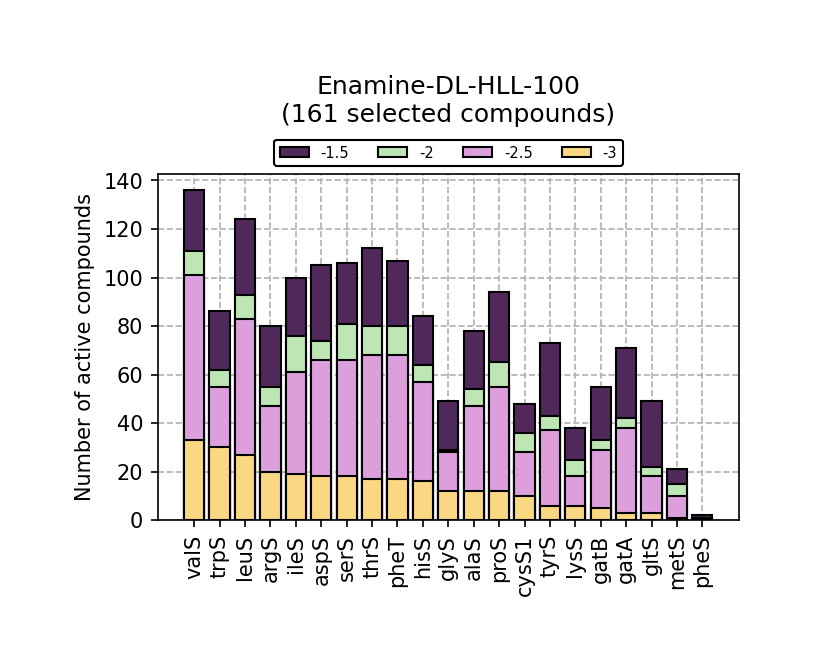

In [58]:
CUTOFFS = [-1.5, -2, -2.5, -3]
COLORS = ['#50285A', '#BEE6B4', '#DC9FDC', '#FAD782']

targets = []
for protein in PROTEINS:
    t = []
    for cut in CUTOFFS:
        t.append(len([sel for sel in SELECTED_COMPOUNDS if sel in PROTEIN_TO_HITS[protein][cut]]))
    targets.append(t)
targets = np.array(targets)
indices = np.argsort(targets[:, -1])[::-1]
targets = targets[indices]
GENES = np.array([uniprot_to_gene[i] for i in PROTEINS])[indices]

fig, ax = plt.subplots(1, 1, figsize=(5, 3), dpi=150)
ax.grid(linestyle='--', zorder=-2)
ax.set_ylabel("Number of active compounds")
ax.set_xticks([i for i in range(len(GENES))])
ax.set_xticklabels([i for i in GENES], rotation=90)
for x, target in enumerate(targets):
    for c, t in enumerate(target):
        if x != 0:
            ax.bar(x, t, edgecolor='k', color=COLORS[c], zorder=2)
        else:
            ax.bar(x, t, edgecolor='k', color=COLORS[c], zorder=2, label=CUTOFFS[c])

ax.set_title(f"{lib}\n({len(SELECTED_COMPOUNDS)} selected compounds)", pad=25)
ax.legend(framealpha=1, edgecolor='k', loc='center', prop={"size": 7}, ncol=4, title_fontsize=7.5, bbox_to_anchor=(0.5, 1.06))
plt.show()

# targets = pd.DataFrame(targets, columns=["score_12", "score_11", "score_10", "score_9", 'score_8'])
# targets['gene_name'] = GENES
# targets = targets[['gene_name', "score_12", "score_11", "score_10", "score_9"]]
# targets.to_csv(os.path.join(PATH_TO_OUTPUT, f"proteins_{LIBRARY}.csv"), index=False)

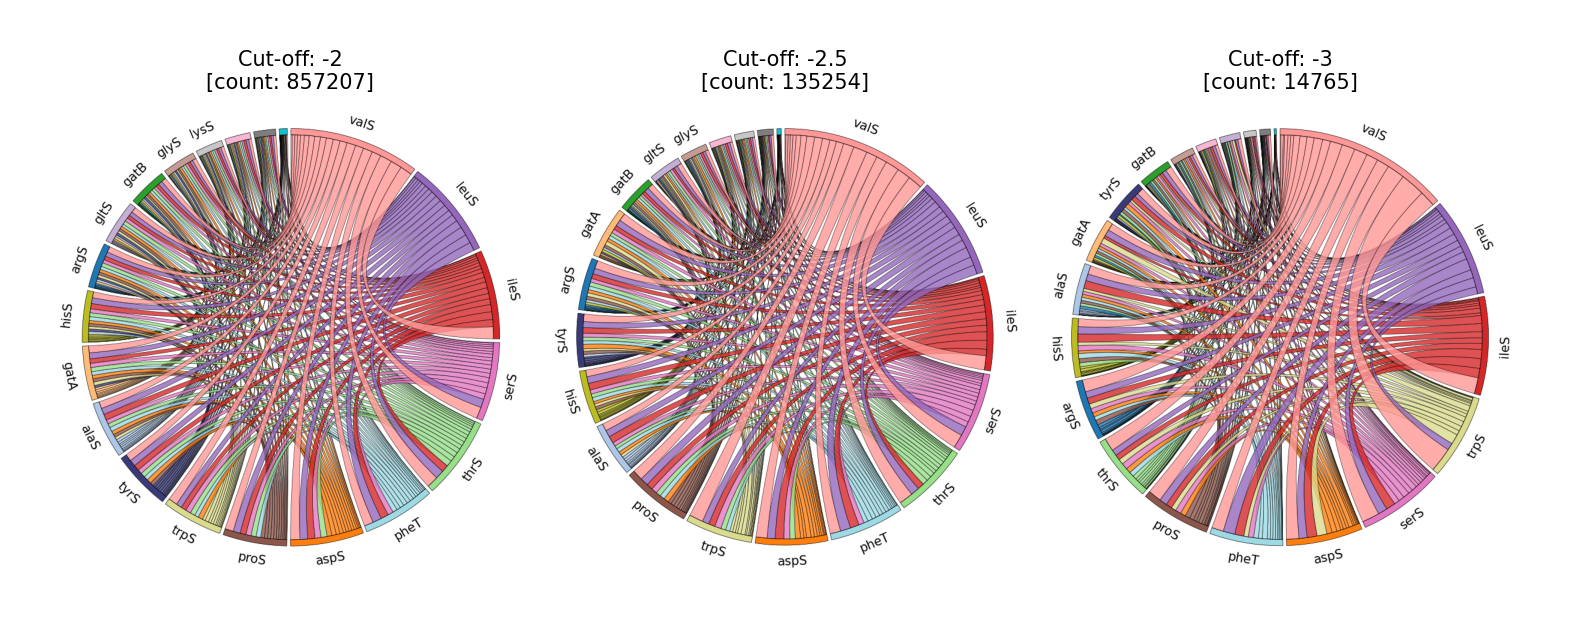

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))


uniprot_ids = ["P9WFW5","P9WFW7","P9WFW3","P9WQA1","P9WN61","P9WFT5","P9WFV3","P9WFS9","P9WFV1","P9WFV9","P9WFT9","P9WFV7","P9WFT7",
            "P9WFW1","P9WFU5","P9WFU9","P9WFV5","P9WFT3","P9WFU3","P9WFU1","P9WFT1"]

palette = list(plt.get_cmap("tab20").colors) + [plt.get_cmap("tab20b").colors[0]]
cmap_dict = {uniprot_to_gene[uid]: to_hex(palette[i]) for i, uid in enumerate(uniprot_ids)}

def get_hit_overlap(h1, h2):
        return len(h1.intersection(h2))

for count, cut in enumerate([-2, -2.5, -3]):


    HIT_OVERLAP = {}
    for c1, p1 in enumerate(PROTEINS):
        for p2 in PROTEINS[c1:]:
            set1 = PROTEIN_TO_HITS[p1][cut]
            set2 = PROTEIN_TO_HITS[p2][cut]
            ov = get_hit_overlap(set1, set2)
            HIT_OVERLAP[(p1, p2)] = ov
            HIT_OVERLAP[(p2, p1)] = ov

    # Circos plot
    row_names = PROTEINS
    matrix = [[HIT_OVERLAP[(i, j)] for j in row_names] for i in row_names]
    matrix_df = pd.DataFrame(matrix, index=row_names, columns=row_names)
    np.fill_diagonal(matrix_df.values, 0)
    node_strength = matrix_df.sum(axis=0) + matrix_df.sum(axis=1)
    order = node_strength.sort_values(ascending=False).index
    matrix_df = matrix_df.loc[order, order]
    matrix_df_genes = matrix_df.rename(index=uniprot_to_gene).rename(columns=uniprot_to_gene)
    node_strength = (matrix_df_genes.sum(axis=0) + matrix_df_genes.sum(axis=1)) / 2
    total_sum = matrix_df_genes.values.sum() / 2
    thr = total_sum / 25
    rename_map = {}
    c = 1
    for g in matrix_df_genes.index:
        if node_strength.loc[g] < thr:
            rename_map[g] = " " * c
            cmap_dict[" " * c] = cmap_dict[g]
            c += 1
    matrix_df_plot = matrix_df_genes.rename(index=rename_map).rename(columns=rename_map)
    matrix_df_plot.values[np.tril_indices_from(matrix_df_plot, k=1)] = 0
    circos = Circos.chord_diagram(
        matrix_df_plot,
        space=1,
        cmap=cmap_dict,
        label_kws=dict(size=15),
        link_kws=dict(ec="k", lw=0.5, alpha=0.8))
    plot = circos.plotfig()
    canvas = FigureCanvas(plot)
    canvas.draw()
    w, h = plot.canvas.get_width_height()
    img = np.frombuffer(canvas.tostring_argb(), dtype=np.uint8).reshape(h, w, 4)[:, :, [1,2,3,0]] 
    ax[count].set_title(f"Cut-off: {cut}\n[count: {int(total_sum)}]", size=15)
    ax[count].imshow(img)
    ax[count].axis("off")
    plt.close(plot)


plt.tight_layout()
plt.show()